# 基于宏观经济指标的地方财政收入关联因素分析与预测

## 1. 项目背景与分析目标

地方财政收入反映了地方政府筹集公共资金和提供公共服务的能力，并与经济规模、居民收入、消费、投资和税收等多项宏观经济指标有关。

本项目使用1994—2013年的年度数据，分析13项宏观经济指标与地方财政收入之间的关联，并预测2014年和2015年的财政收入。

### 1.1 分析目标

- 描述地方财政收入及相关宏观经济指标的长期变化趋势；
- 区分共同时间趋势与相对稳定的变量关联；
- 检查并处理解释变量之间的多重共线性；
- 使用时间顺序测试和滚动回测评估模型；
- 在避免目标泄漏的前提下预测未来财政收入；
- 给出预测区间并说明模型不确定性。

### 1.2 分析方法

本项目依次使用描述性统计、同比增长率、一阶差分相关性、VIF、对数线性趋势、Ridge、Elastic Net、时间序列交叉验证和滚动回测完成分析。

### 1.3 数据局限

数据仅包含20个年度样本，且原始资料没有明确注明地区和部分变量的统计单位。因此，本项目将相关性和模型系数解释为预测关联，不直接解释为因果影响。

## 2. 数据准备与质量检查

### 2.1 数据读取与字段设置

首先读取原始数据并添加1994—2013年的年份字段。为了避免后续发生目标泄漏，将13个宏观经济指标明确设置为候选解释变量，将地方财政收入 `y` 单独设置为预测目标。

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

# 使用相对路径读取数据
data = pd.read_csv("revenue.csv")

# 检查原始字段
expected_columns = [f"x{i}" for i in range(1, 14)] + ["y"]

if list(data.columns) != expected_columns:
    raise ValueError(
        f"字段与预期不一致。\n"
        f"预期字段：{expected_columns}\n"
        f"实际字段：{list(data.columns)}"
    )

# 数据对应1994—2013年
years = np.arange(1994, 2014)

if len(data) != len(years):
    raise ValueError(
        f"数据共有{len(data)}行，与1994—2013年的20个年度不一致。"
    )

data.insert(0, "year", years)

# 明确划分特征和目标变量，防止后续目标泄漏
feature_cols = [f"x{i}" for i in range(1, 14)]
target_col = "y"

assert target_col not in feature_cols
assert len(feature_cols) == 13

print("数据读取完成")
print("数据维度：", data.shape)
print("年份范围：", data["year"].min(), "—", data["year"].max())

display(data.head())

数据读取完成
数据维度： (20, 15)
年份范围： 1994 — 2013


,year,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,y
0,1994,3831732,181.54,448.19,"7,571.00","6,212.70",6370241,525.71,985.31,60.62,65.66,120.00,1.03,5321,64.87
1,1995,3913824,214.63,549.97,"9,038.16","7,601.73",6467115,618.25,"1,259.20",73.46,95.46,113.50,1.05,6529,99.75
2,1996,3928907,239.56,686.44,"9,905.31","8,092.82",6560508,638.94,"1,468.06",81.16,81.16,108.20,1.06,7008,88.11
3,1997,4282130,261.58,802.59,"10,444.60","8,767.98",6664862,656.58,"1,678.12",85.72,91.70,102.20,1.09,7694,106.07
4,1998,4453911,283.14,904.57,"11,255.70","9,422.33",6741400,758.83,"1,893.52",88.88,114.61,97.70,1.20,8027,137.32


### 2.2 变量说明

数据集包含13个候选解释变量和1个财政收入目标变量。为了保持与原始数据一致，代码中继续使用 `x1`—`x13` 和 `y` 作为字段名称，同时建立中文数据字典说明各变量含义。

由于原始资料没有提供完整统计单位，数据字典暂时将单位标记为“原始资料未注明”，避免自行补充无法验证的信息。

In [2]:
variable_names = {
    "year": "年份",
    "x1": "社会从业人数",
    "x2": "在岗职工工资总额",
    "x3": "社会消费品零售总额",
    "x4": "城镇居民人均可支配收入",
    "x5": "城镇居民人均消费性支出",
    "x6": "年末总人口",
    "x7": "全社会固定资产投资额",
    "x8": "地区生产总值",
    "x9": "第一产业产值",
    "x10": "税收",
    "x11": "居民消费价格指数",
    "x12": "第三产业与第二产业产值比",
    "x13": "居民消费水平",
    "y": "地方财政收入"
}

data_dictionary = pd.DataFrame({
    "字段": list(variable_names.keys()),
    "变量名称": list(variable_names.values()),
    "变量角色": [
        "时间变量",
        *["候选解释变量"] * 13,
        "预测目标"
    ],
    "单位": [
        "年",
        *["原始资料未注明"] * 13,
        "原始资料未注明"
    ]
})

display(data_dictionary)

,字段,变量名称,变量角色,单位
0,year,年份,时间变量,年
1,x1,社会从业人数,候选解释变量,原始资料未注明
2,x2,在岗职工工资总额,候选解释变量,原始资料未注明
3,x3,社会消费品零售总额,候选解释变量,原始资料未注明
4,x4,城镇居民人均可支配收入,候选解释变量,原始资料未注明
5,x5,城镇居民人均消费性支出,候选解释变量,原始资料未注明
6,x6,年末总人口,候选解释变量,原始资料未注明
7,x7,全社会固定资产投资额,候选解释变量,原始资料未注明
8,x8,地区生产总值,候选解释变量,原始资料未注明
9,x9,第一产业产值,候选解释变量,原始资料未注明


### 2.3 数据质量检查

在正式分析前，检查数据类型、缺失值、无穷值、重复记录和变量唯一值数量，确保后续统计分析和模型训练使用的数据完整、有效。

In [3]:
numeric_cols = feature_cols + [target_col]

quality_check = pd.DataFrame({
    "数据类型": data[numeric_cols].dtypes.astype(str),
    "缺失数量": data[numeric_cols].isna().sum(),
    "缺失比例": data[numeric_cols].isna().mean(),
    "唯一值数量": data[numeric_cols].nunique()
})

duplicate_count = data.duplicated().sum()
infinite_count = np.isinf(data[numeric_cols]).sum().sum()
missing_count = data[numeric_cols].isna().sum().sum()

print("数据质量检查")
print("-" * 40)
print(f"样本数量：{len(data)}")
print(f"变量数量：{len(numeric_cols)}")
print(f"重复记录：{duplicate_count}")
print(f"无穷值数量：{infinite_count}")
print(f"缺失值总数：{missing_count}")

display(quality_check)

数据质量检查
----------------------------------------
样本数量：20
变量数量：14
重复记录：0
无穷值数量：0
缺失值总数：0


,数据类型,缺失数量,缺失比例,唯一值数量
x1,int64,0,0.00,20
x2,float64,0,0.00,20
x3,float64,0,0.00,20
x4,float64,0,0.00,20
x5,float64,0,0.00,20
x6,int64,0,0.00,20
x7,float64,0,0.00,20
x8,float64,0,0.00,20
x9,float64,0,0.00,20
x10,float64,0,0.00,20


#### 数据质量检查结果

数据集包含20个年度样本和14个数值变量。检查结果显示：

- 数据不存在缺失值；
- 数据不存在无穷值；
- 数据不存在重复记录；
- 各字段均为数值类型；
- 除 `x12` 有一个重复取值外，其余变量在20个年度中均有20个不同取值。

`x12` 的唯一值数量为19，只表示有两个年度的第三产业与第二产业产值比相同，不属于数据质量问题。综合来看，原始数据可以进入后续分析，无需进行缺失值填补或重复值删除。

### 2.4 描述性统计

通过均值、标准差、分位数和取值范围了解各变量的分布特征，并判断不同变量之间是否存在明显的数量级差异。

In [4]:
descriptive_stats = (
    data[numeric_cols]
    .describe()
    .T
    .rename(columns={
        "count": "样本量",
        "mean": "均值",
        "std": "标准差",
        "min": "最小值",
        "25%": "25%分位数",
        "50%": "中位数",
        "75%": "75%分位数",
        "max": "最大值"
    })
    .round(2)
)

display(descriptive_stats)

,样本量,均值,标准差,最小值,25%分位数,中位数,75%分位数,最大值
x1,20.00,"5,579,519.95","1,262,194.72","3,831,732.00","4,525,116.75","5,308,896.50","6,594,657.50","7,599,295.00"
x2,20.00,765.04,595.70,181.54,302.22,565.94,"1,033.54","2,110.78"
x3,20.00,"2,370.83","1,919.17",448.19,976.66,"1,586.02","3,294.48","6,882.85"
x4,20.00,"19,644.69","10,203.02","7,571.00","11,827.82","15,943.38","25,889.94","42,049.14"
x5,20.00,"15,870.95","8,199.77","6,212.70","9,669.16","12,345.70","21,332.18","33,156.83"
x6,20.00,"7,350,513.60","621,341.85","6,370,241.00","6,822,868.00","7,314,304.00","7,867,809.75","8,323,096.00"
x7,20.00,"1,712.24","1,184.71",525.71,848.40,"1,262.05","2,244.12","4,454.55"
x8,20.00,"5,705.80","4,478.40",985.31,"2,077.76","4,104.58","8,500.09","15,420.14"
x9,20.00,129.49,50.51,60.62,91.86,113.53,169.96,228.46
x10,20.00,340.22,251.58,65.66,143.24,235.76,521.06,852.56


#### 描述性统计结论

描述性统计结果显示，不同变量之间存在明显的数量级差异。例如，社会从业人数和年末总人口为百万级，而第三产业与第二产业产值比约为1。因此，后续正则化回归模型不能直接使用原始尺度，需要在训练流程中进行标准化。

地方财政收入的均值为618.08，中位数为319.50，最大值达到2088.14。均值明显高于中位数，说明财政收入在样本后期出现了较快增长。多个宏观经济指标也呈现类似特征，因此需要进一步分析时间趋势和年度增长率。

由于数据属于年度时间序列，后期较大的数值不能直接认定为异常值，需要结合年份和增长变化进行判断。

## 3. 时间趋势与增长率分析

### 3.1 地方财政收入变化趋势

首先分析1994—2013年地方财政收入的长期变化和同比增长率，判断序列是否存在明显趋势、年度波动或结构变化。

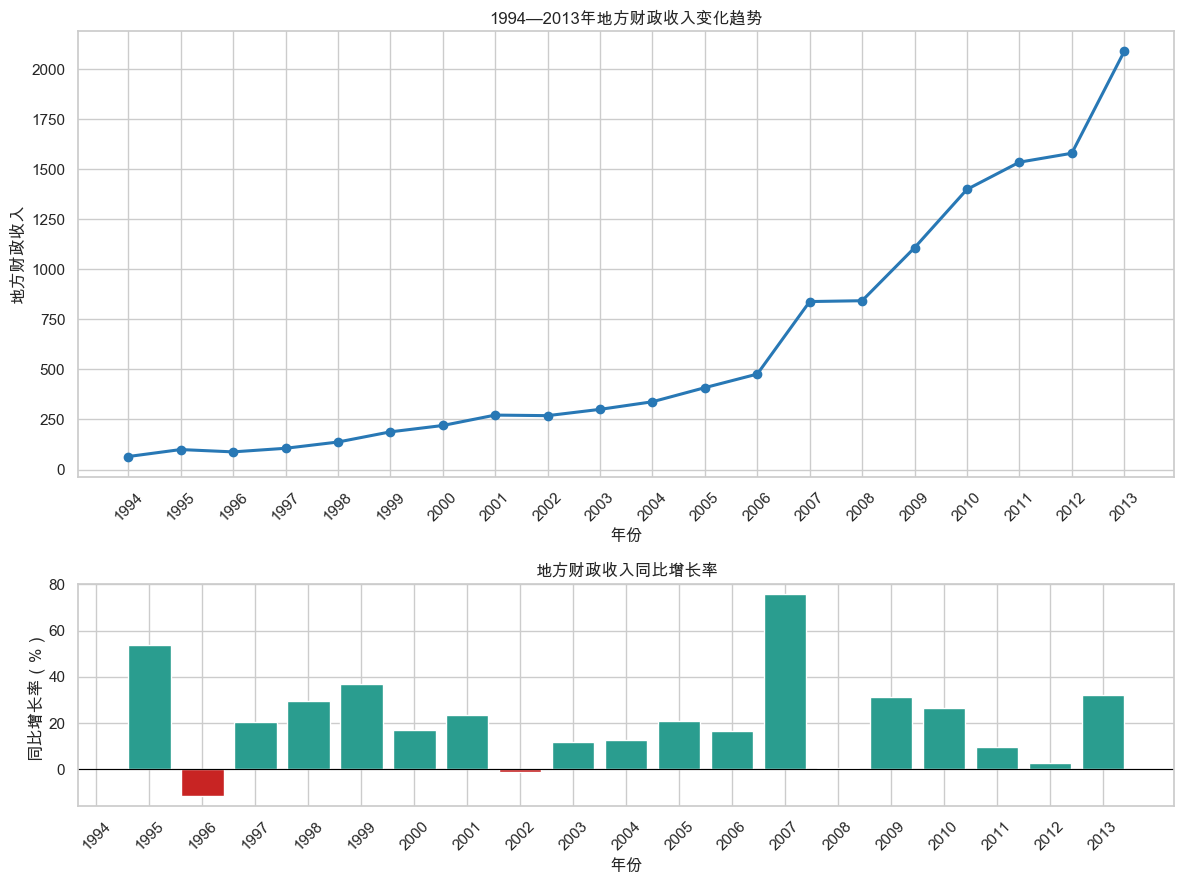

1994—2013年财政收入复合年均增长率：20.05%


,year,y,同比增长率
0,1994,64.87,NaN
1,1995,99.75,53.77
2,1996,88.11,-11.67
3,1997,106.07,20.38
4,1998,137.32,29.46
5,1999,188.14,37.01
6,2000,219.91,16.89
7,2001,271.91,23.65
8,2002,269.10,-1.03
9,2003,300.55,11.69


In [5]:
# 构建财政收入趋势数据
revenue_trend = data[["year", target_col]].copy()
revenue_trend["同比增长率"] = revenue_trend[target_col].pct_change() * 100

# 计算复合年均增长率
start_value = revenue_trend[target_col].iloc[0]
end_value = revenue_trend[target_col].iloc[-1]
number_of_years = len(revenue_trend) - 1

cagr = (end_value / start_value) ** (1 / number_of_years) - 1

# 设置中文字体
plt.rcParams["font.sans-serif"] = [
    "SimHei",
    "Microsoft YaHei",
    "Arial Unicode MS"
]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 9),
    gridspec_kw={"height_ratios": [2, 1]}
)

# 财政收入趋势
axes[0].plot(
    revenue_trend["year"],
    revenue_trend[target_col],
    marker="o",
    linewidth=2.2,
    color="#2878B5"
)

axes[0].set_title("1994—2013年地方财政收入变化趋势")
axes[0].set_xlabel("年份")
axes[0].set_ylabel("地方财政收入")
axes[0].set_xticks(revenue_trend["year"])
axes[0].tick_params(axis="x", rotation=45)

# 同比增长率
growth_colors = [
    "#C82423" if value < 0 else "#2A9D8F"
    for value in revenue_trend["同比增长率"].fillna(0)
]

axes[1].bar(
    revenue_trend["year"],
    revenue_trend["同比增长率"],
    color=growth_colors
)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("地方财政收入同比增长率")
axes[1].set_xlabel("年份")
axes[1].set_ylabel("同比增长率（%）")
axes[1].set_xticks(revenue_trend["year"])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"1994—2013年财政收入复合年均增长率：{cagr:.2%}")

display(revenue_trend.round(2))

#### 财政收入趋势分析结论

1994—2013年，地方财政收入从64.87增长至2088.14，复合年均增长率约为20.05%，整体呈现明显的长期上升趋势。

但财政收入并非保持稳定增长。1996年和2002年分别下降11.67%和1.03%；2007年同比增长率达到75.99%，为样本期内最高水平；2008年的增长率则只有0.49%。这说明财政收入除长期增长趋势外，还存在明显的年度波动和可能的结构变化。

由于财政收入具有明显的非平稳增长特征，后续不能只分析原始数值之间的相关性，还需要比较变量变化量之间的关系。

### 3.2 宏观经济指标标准化趋势对比

各宏观经济指标的数量级差异较大，因此将变量转换为标准化数值，仅用于比较不同指标与地方财政收入的时间变化趋势。这里的标准化属于可视化处理，不用于提前拟合后续模型。

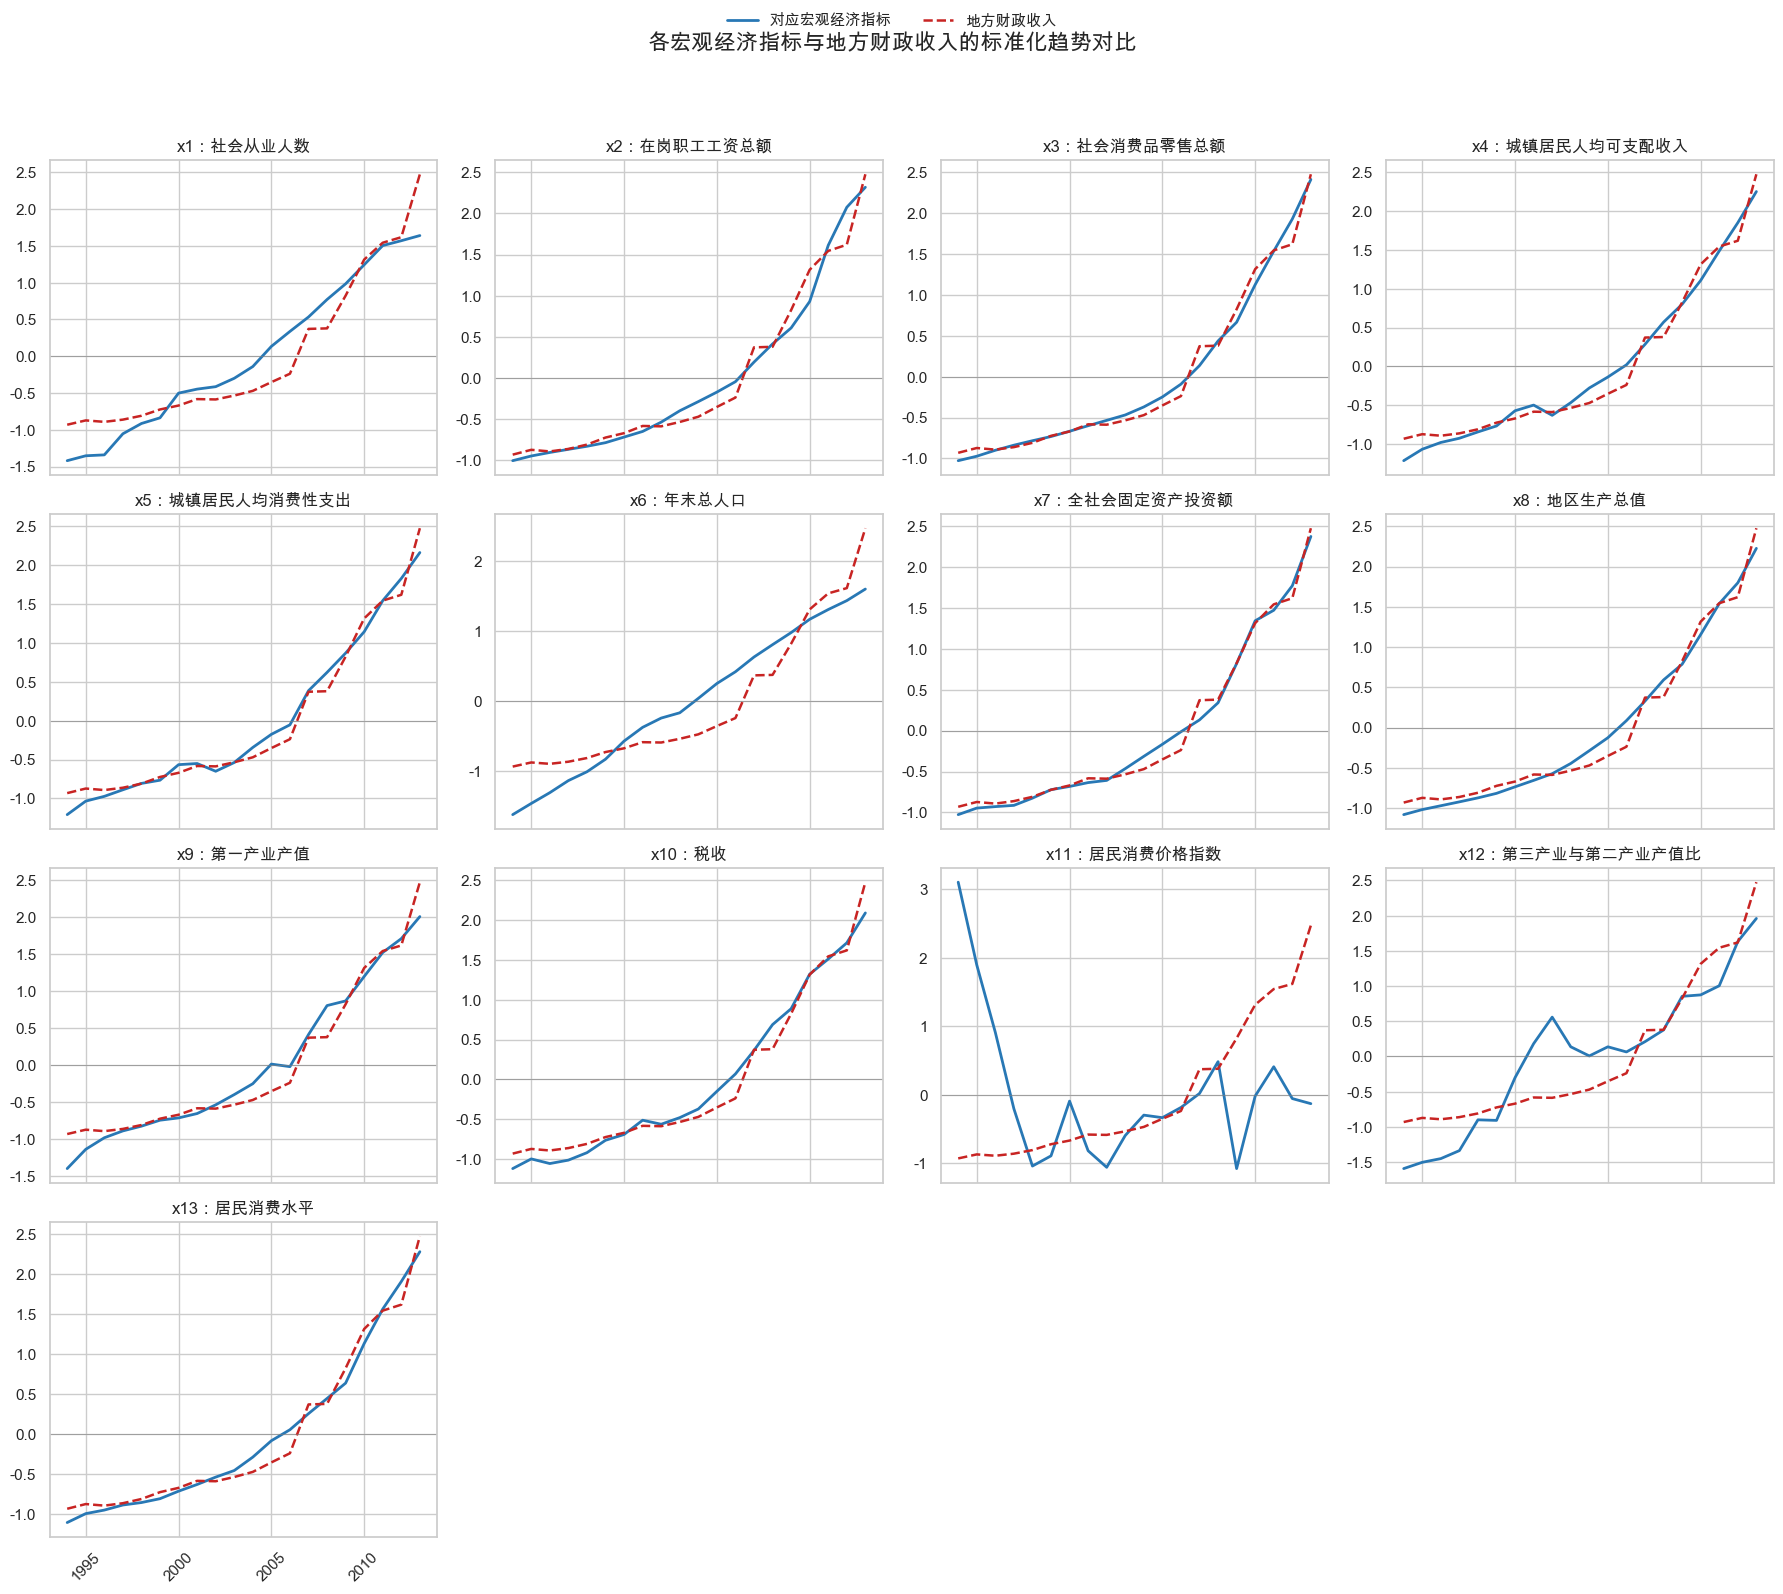

In [6]:
# 对全部变量进行标准化，仅用于趋势可视化
standardized_trend = data[["year"]].copy()

for col in numeric_cols:
    standardized_trend[col] = (
        data[col] - data[col].mean()
    ) / data[col].std(ddof=0)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(18, 16),
    sharex=True
)

axes = axes.flatten()

for index, col in enumerate(feature_cols):
    ax = axes[index]

    ax.plot(
        standardized_trend["year"],
        standardized_trend[col],
        color="#2878B5",
        linewidth=2,
        label="对应宏观经济指标"
    )

    ax.plot(
        standardized_trend["year"],
        standardized_trend[target_col],
        color="#C82423",
        linewidth=1.8,
        linestyle="--",
        label="地方财政收入"
    )

    ax.axhline(0, color="gray", linewidth=0.7, alpha=0.6)
    ax.set_title(f"{col}：{variable_names[col]}")
    ax.tick_params(axis="x", rotation=45)

# 删除多余的空白子图
for index in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[index])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "各宏观经济指标与地方财政收入的标准化趋势对比",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### 标准化趋势对比结论

标准化趋势显示，多数宏观经济指标与地方财政收入都呈现长期上升趋势。其中，在岗职工工资总额、社会消费品零售总额、居民收入、固定资产投资、地区生产总值、税收和居民消费水平在样本后期均出现加速增长，与财政收入的整体走势较为接近。

社会从业人数和年末总人口的增长相对平稳，没有完全跟随财政收入的年度跳升；居民消费价格指数主要表现为上下波动，与财政收入的走势明显不同；第三产业与第二产业产值比虽然长期上升，但中间波动较为明显。

趋势相似并不一定代表变量之间存在稳定的影响关系。多个指标可能只是同时受到经济增长和年份变化影响，从而在原始数据中产生较高相关性。

## 4. 相关性与共同趋势分析

### 4.1 原始值与一阶差分相关性比较

首先计算各宏观经济指标与地方财政收入原始值之间的Pearson相关系数。随后对变量进行一阶差分，即使用本年度数值减去上一年度数值，再比较各指标变化量与财政收入变化量之间的相关性。

该方法用于初步判断原始数据中的高相关性是否主要来自共同时间趋势。

In [7]:
analysis_cols = feature_cols + [target_col]

# 原始数值相关性
level_corr = (
    data[analysis_cols]
    .corr(method="pearson")[target_col]
    .drop(target_col)
)

# 一阶差分：本年度数值减去上一年度数值
diff_data = data[analysis_cols].diff().dropna()

diff_corr = (
    diff_data
    .corr(method="pearson")[target_col]
    .drop(target_col)
)

# 各变量与年份的相关性
year_corr = data[feature_cols].corrwith(data["year"])

corr_comparison = pd.DataFrame({
    "变量名称": [variable_names[col] for col in feature_cols],
    "与年份相关系数": year_corr,
    "原始值与财政收入相关系数": level_corr,
    "一阶差分与财政收入差分相关系数": diff_corr
})

corr_comparison["绝对相关性变化（原始减差分）"] = (
    corr_comparison["原始值与财政收入相关系数"].abs()
    - corr_comparison["一阶差分与财政收入差分相关系数"].abs()
)

corr_comparison = corr_comparison.sort_values(
    "原始值与财政收入相关系数",
    ascending=False
)

display(corr_comparison.round(3))

,变量名称,与年份相关系数,原始值与财政收入相关系数,一阶差分与财政收入差分相关系数,绝对相关性变化（原始减差分）
x7,全社会固定资产投资额,0.93,0.99,0.78,0.21
x3,社会消费品零售总额,0.92,0.99,0.68,0.32
x5,城镇居民人均消费性支出,0.95,0.99,0.66,0.33
x8,地区生产总值,0.95,0.99,0.72,0.27
x13,居民消费水平,0.94,0.99,0.62,0.37
x4,城镇居民人均可支配收入,0.95,0.99,0.60,0.39
x10,税收,0.96,0.99,0.70,0.28
x2,在岗职工工资总额,0.92,0.98,0.35,0.63
x9,第一产业产值,0.97,0.97,0.46,0.51
x1,社会从业人数,0.99,0.94,0.09,0.84


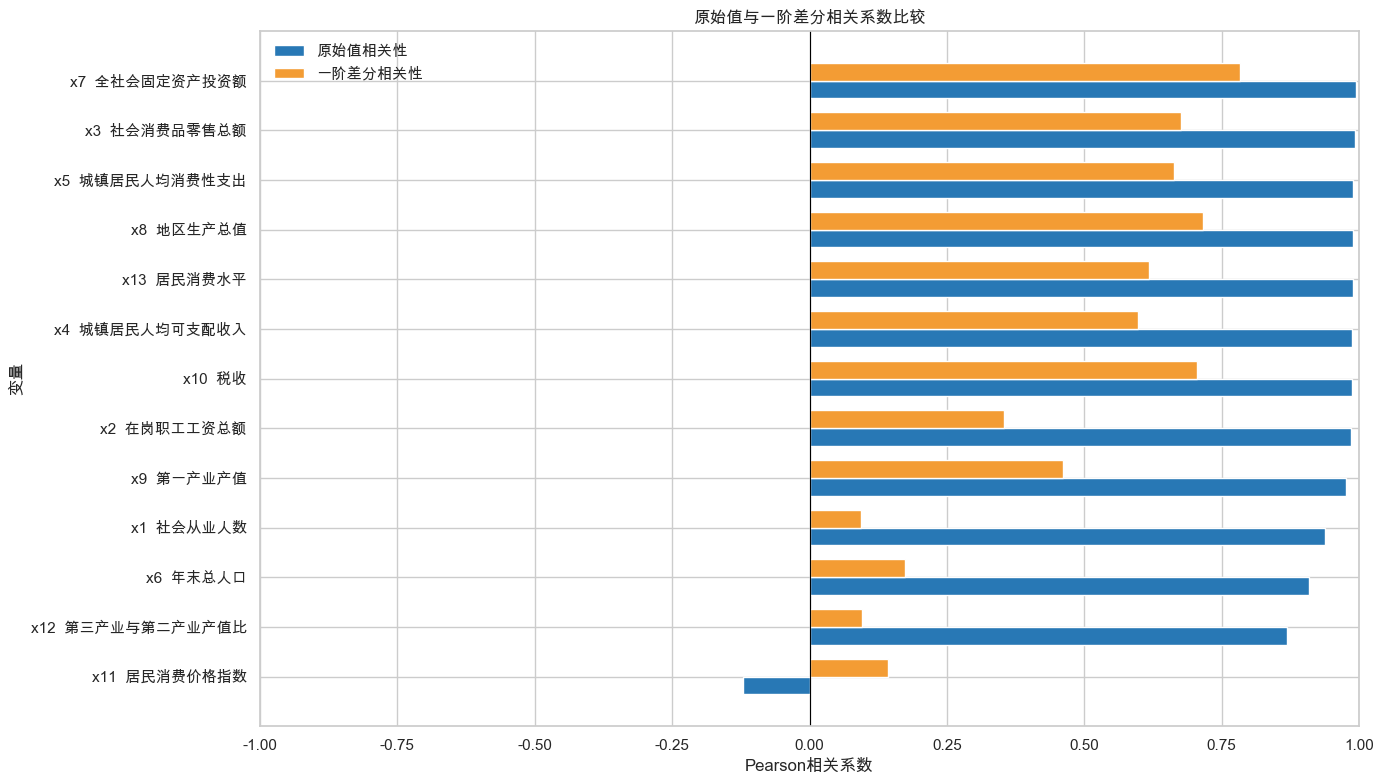

In [8]:
plot_corr = corr_comparison.sort_values(
    "原始值与财政收入相关系数",
    ascending=True
)

positions = np.arange(len(plot_corr))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(14, 8))

ax.barh(
    positions - bar_height / 2,
    plot_corr["原始值与财政收入相关系数"],
    height=bar_height,
    color="#2878B5",
    label="原始值相关性"
)

ax.barh(
    positions + bar_height / 2,
    plot_corr["一阶差分与财政收入差分相关系数"],
    height=bar_height,
    color="#F39C34",
    label="一阶差分相关性"
)

ax.set_yticks(positions)
plot_labels = [
    f"{index}  {plot_corr.loc[index, '变量名称']}"
    for index in plot_corr.index
]

ax.set_yticklabels(plot_labels)
ax.set_xlim(-1, 1)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title("原始值与一阶差分相关系数比较")
ax.set_xlabel("Pearson相关系数")
ax.set_ylabel("变量")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

#### 原始值与一阶差分相关性结论

原始数据中，除居民消费价格指数外，大多数宏观经济指标与地方财政收入的相关系数均超过0.90。但多数指标本身也与年份高度相关，说明原始相关性受到共同增长趋势影响。

进行一阶差分后，不同变量之间出现明显差异：

- 全社会固定资产投资额的一阶差分相关系数为0.784；
- 地区生产总值为0.716；
- 税收为0.705；
- 社会消费品零售总额为0.676；
- 城镇居民人均消费性支出为0.664；
- 居民消费水平为0.618；
- 城镇居民人均可支配收入为0.597。

相比之下，社会从业人数、年末总人口和第三产业与第二产业产值比的一阶差分相关系数分别降至0.093、0.173和0.096，说明这些变量在原始数据中的高相关性主要来自长期时间趋势。

一阶差分后仅剩19个年度变化样本，因此这些结果主要用于探索性分析和变量筛选，不能直接解释为因果关系。

## 5. 多重共线性分析

### 5.1 解释变量相关性矩阵

除了分析各变量与财政收入的关系，还需要检查13个解释变量彼此之间的相关性。如果多个解释变量包含高度重复的信息，普通线性回归的系数可能变得不稳定。

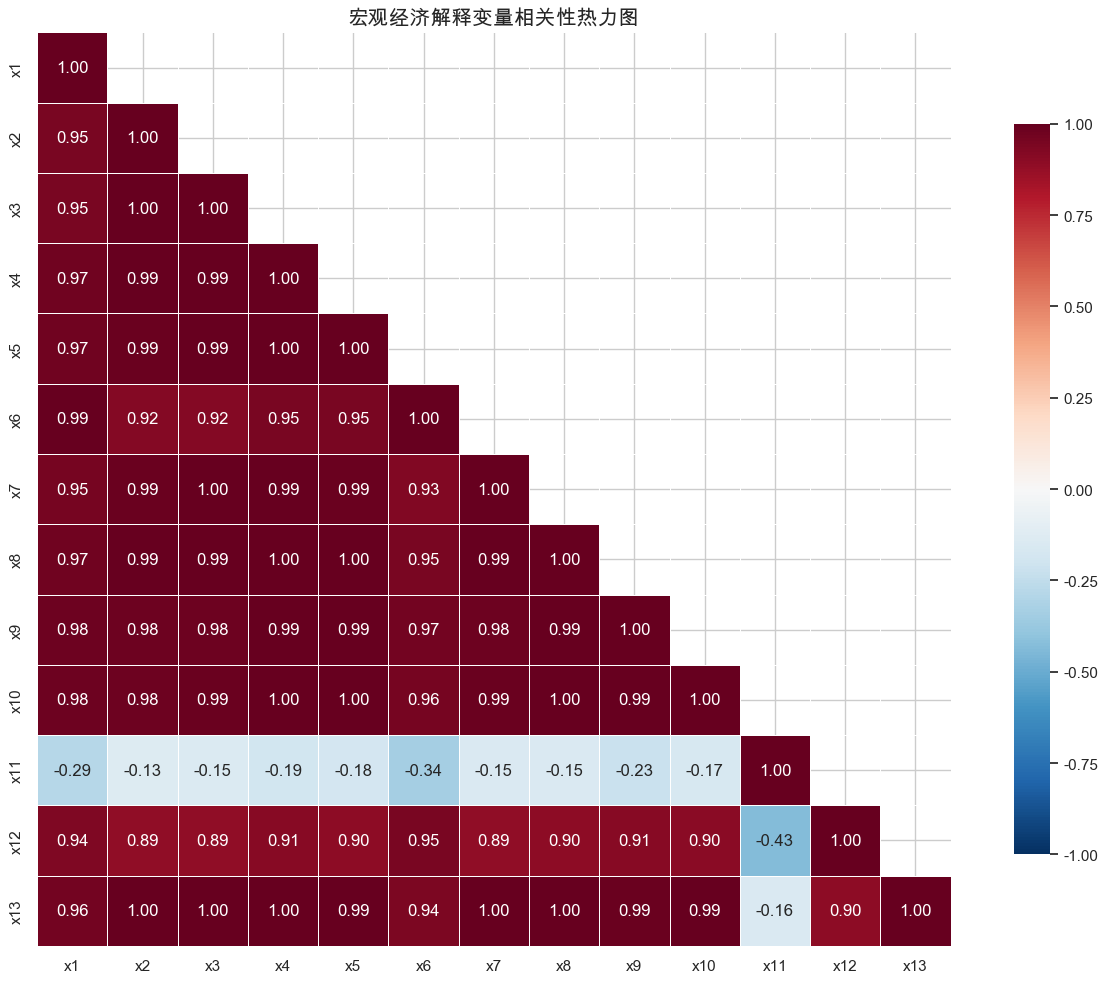

In [9]:
feature_corr = data[feature_cols].corr(method="pearson")

# 隐藏热力图上三角，避免重复显示
mask = np.triu(
    np.ones_like(feature_corr, dtype=bool),
    k=1
)

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    feature_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("宏观经济解释变量相关性热力图", fontsize=15)

plt.tight_layout()
plt.show()

In [10]:
upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "变量1",
    "变量2",
    "相关系数"
]

high_corr_pairs["绝对相关系数"] = (
    high_corr_pairs["相关系数"].abs()
)

high_corr_pairs["变量1名称"] = (
    high_corr_pairs["变量1"].map(variable_names)
)

high_corr_pairs["变量2名称"] = (
    high_corr_pairs["变量2"].map(variable_names)
)

high_corr_pairs = (
    high_corr_pairs
    .sort_values("绝对相关系数", ascending=False)
    .head(15)
)

display(
    high_corr_pairs[
        [
            "变量1",
            "变量1名称",
            "变量2",
            "变量2名称",
            "相关系数"
        ]
    ].round(3)
)

,变量1,变量1名称,变量2,变量2名称,相关系数
33,x4,城镇居民人均可支配收入,x5,城镇居民人均消费性支出,1.00
67,x8,地区生产总值,x13,居民消费水平,1.00
36,x4,城镇居民人均可支配收入,x8,地区生产总值,1.00
12,x2,在岗职工工资总额,x3,社会消费品零售总额,1.00
32,x3,社会消费品零售总额,x13,居民消费水平,1.00
22,x2,在岗职工工资总额,x13,居民消费水平,1.00
44,x5,城镇居民人均消费性支出,x8,地区生产总值,1.00
41,x4,城镇居民人均可支配收入,x13,居民消费水平,1.00
64,x8,地区生产总值,x10,税收,1.00
26,x3,社会消费品零售总额,x7,全社会固定资产投资额,1.00


#### 解释变量相关性结论

相关性热力图显示，除居民消费价格指数外，大多数宏观经济指标之间均存在很强的正相关关系。

相关性最高的变量组合包括：

- 城镇居民人均可支配收入与人均消费性支出；
- 地区生产总值与居民消费水平；
- 在岗职工工资总额与社会消费品零售总额；
- 地区生产总值与税收；
- 社会消费品零售总额与固定资产投资额。

这些变量的相关系数大多接近1，说明它们包含大量重复的经济增长信息。直接将全部变量同时放入普通多元线性回归，可能导致系数符号、大小和变量重要性对少量样本变化非常敏感。

### 5.2 方差膨胀因子

进一步计算方差膨胀因子（VIF），量化每个解释变量能够被其他解释变量解释的程度。通常，VIF超过5需要关注，超过10表示存在严重多重共线性。

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 标准化仅用于提高VIF计算的数值稳定性
scaler_vif = StandardScaler()

X_vif = pd.DataFrame(
    scaler_vif.fit_transform(data[feature_cols]),
    columns=feature_cols
)

vif_results = []

for col in feature_cols:
    other_cols = [
        other_col
        for other_col in feature_cols
        if other_col != col
    ]

    vif_model = LinearRegression()
    vif_model.fit(
        X_vif[other_cols],
        X_vif[col]
    )

    r_squared = vif_model.score(
        X_vif[other_cols],
        X_vif[col]
    )

    vif_value = 1 / (1 - r_squared)

    vif_results.append({
        "变量": col,
        "变量名称": variable_names[col],
        "决定系数R²": r_squared,
        "VIF": vif_value
    })

vif_table = pd.DataFrame(vif_results)

vif_table["共线性判断"] = np.select(
    [
        vif_table["VIF"] < 5,
        vif_table["VIF"] < 10
    ],
    [
        "共线性较低",
        "需要关注"
    ],
    default="严重共线性"
)

vif_table = vif_table.sort_values(
    "VIF",
    ascending=False
)

display(
    vif_table.style.format({
        "决定系数R²": "{:.4f}",
        "VIF": "{:,.2f}"
    })
)

,变量,变量名称,决定系数R²,VIF,共线性判断
2,x3,社会消费品零售总额,0.9997,"3,252.02",严重共线性
7,x8,地区生产总值,0.9997,"2,893.64",严重共线性
3,x4,城镇居民人均可支配收入,0.9995,"2,001.49",严重共线性
4,x5,城镇居民人均消费性支出,0.9994,"1,722.90",严重共线性
12,x13,居民消费水平,0.9993,"1,511.02",严重共线性
5,x6,年末总人口,0.9993,"1,507.90",严重共线性
1,x2,在岗职工工资总额,0.9988,819.73,严重共线性
9,x10,税收,0.9986,735.88,严重共线性
0,x1,社会从业人数,0.9981,516.82,严重共线性
8,x9,第一产业产值,0.9979,477.27,严重共线性


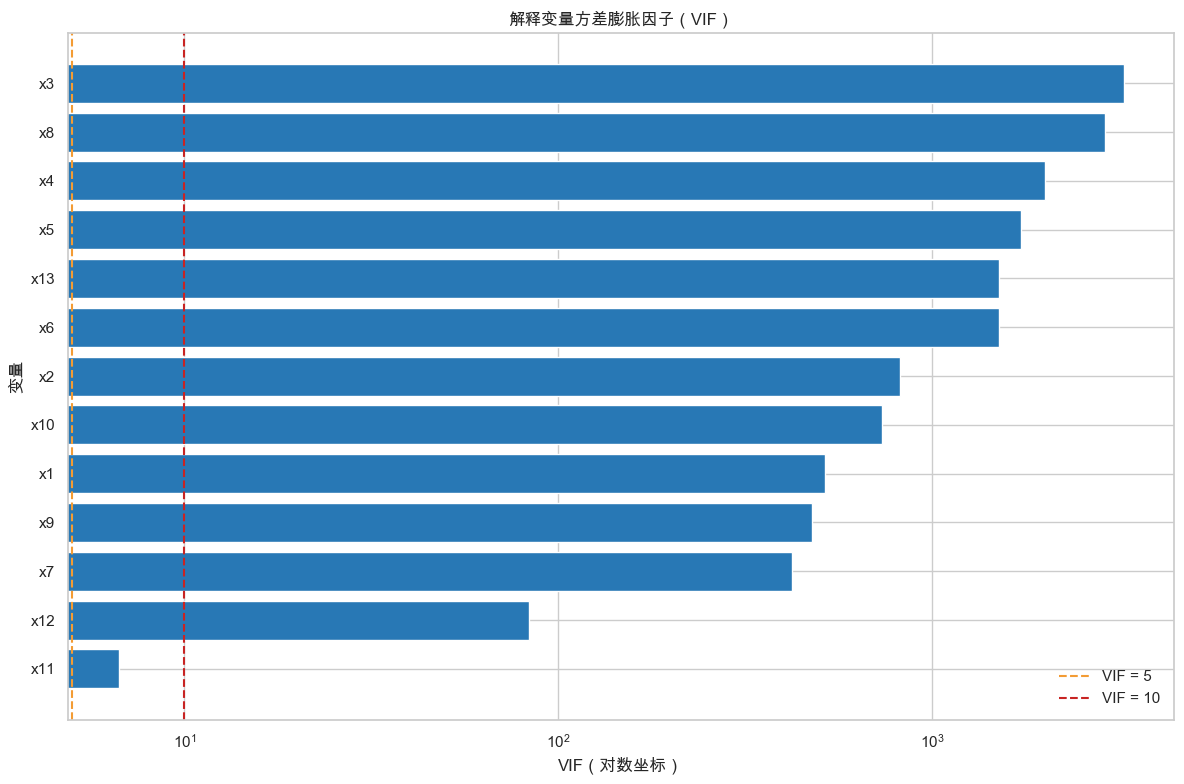

In [12]:
vif_plot = vif_table.sort_values(
    "VIF",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    vif_plot["变量"],
    vif_plot["VIF"],
    color="#2878B5"
)

# VIF跨度很大，使用对数坐标
ax.set_xscale("log")

ax.axvline(
    5,
    color="#F39C34",
    linestyle="--",
    label="VIF = 5"
)

ax.axvline(
    10,
    color="#C82423",
    linestyle="--",
    label="VIF = 10"
)

ax.set_title("解释变量方差膨胀因子（VIF）")
ax.set_xlabel("VIF（对数坐标）")
ax.set_ylabel("变量")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

#### 方差膨胀因子分析结论

VIF结果进一步确认了解释变量之间存在严重多重共线性：

- 社会消费品零售总额的VIF约为3252.02；
- 地区生产总值约为2893.64；
- 城镇居民人均可支配收入约为2001.49；
- 城镇居民人均消费性支出约为1722.90；
- 居民消费水平和年末总人口均超过1500；
- 第三产业与第二产业产值比的VIF也达到83.43；
- 居民消费价格指数的VIF最低，但仍达到6.67。

除居民消费价格指数外，其他变量的VIF均远高于10。直接使用包含全部变量的普通多元线性回归，可能产生不稳定且难以解释的系数。

因此，后续使用Ridge和Elastic Net，通过正则化降低多重共线性造成的影响。所有特征标准化均在模型训练流程内部完成，避免测试集信息提前进入训练过程。

## 6. 模型构建与时间序列评估

### 6.1 时间顺序划分

数据具有明确时间顺序，因此不能使用随机训练测试集划分。本项目使用1994—2009年作为训练集，2010—2013年作为测试集，并确保所有测试年份均晚于训练年份。

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# 按照时间顺序划分数据
train_data = data[data["year"] <= 2009].copy()
test_data = data[data["year"] >= 2010].copy()

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

y_train = train_data[target_col]
y_test = test_data[target_col]

print("训练集年份：",
      train_data["year"].min(),
      "—",
      train_data["year"].max())

print("测试集年份：",
      test_data["year"].min(),
      "—",
      test_data["year"].max())

print("训练集样本数：", len(train_data))
print("测试集样本数：", len(test_data))

assert target_col not in X_train.columns
assert target_col not in X_test.columns
assert train_data["year"].max() < test_data["year"].min()

训练集年份： 1994 — 2009
测试集年份： 2010 — 2013
训练集样本数： 16
测试集样本数： 4


### 6.2 评估指标与基准模型

为统一比较不同模型，使用以下回归指标：

- **MAE**：预测值与实际值之间绝对误差的平均值；
- **RMSE**：对较大预测误差给予更高惩罚；
- **MAPE**：平均绝对百分比误差，便于比较不同规模数值；
- **R²**：衡量模型对测试集变化的解释程度。

首先建立三个不使用宏观解释变量的基准模型：

1. 使用2009年财政收入预测全部测试年份；
2. 使用普通线性时间趋势预测；
3. 对财政收入取对数后建立对数线性趋势模型。

后续正则化模型只有在相同测试集上的表现优于这些简单基准时，才能说明宏观经济指标提供了额外预测信息。

In [14]:
def calculate_regression_metrics(
    model_name,
    y_true,
    y_pred
):
    return {
        "模型": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAPE": mean_absolute_percentage_error(
            y_true,
            y_pred
        ) * 100,
        "R²": r2_score(y_true, y_pred)
    }

In [15]:
baseline_predictions = pd.DataFrame({
    "year": test_data["year"].values,
    "实际值": y_test.values
})

baseline_results = []

# 基准模型1：以2009年的财政收入预测所有测试年份
last_value_prediction = np.full(
    len(test_data),
    y_train.iloc[-1]
)

baseline_predictions["上一期数值基准"] = (
    last_value_prediction
)

baseline_results.append(
    calculate_regression_metrics(
        "上一期数值基准",
        y_test,
        last_value_prediction
    )
)

# 基准模型2：普通线性时间趋势
linear_trend_model = LinearRegression()

linear_trend_model.fit(
    train_data[["year"]],
    y_train
)

linear_trend_prediction = (
    linear_trend_model.predict(
        test_data[["year"]]
    )
)

baseline_predictions["线性趋势"] = (
    linear_trend_prediction
)

baseline_results.append(
    calculate_regression_metrics(
        "线性趋势",
        y_test,
        linear_trend_prediction
    )
)

# 基准模型3：对数线性趋势
# 适用于呈近似复合增长的正数序列
log_trend_model = LinearRegression()

log_trend_model.fit(
    train_data[["year"]],
    np.log(y_train)
)

log_trend_prediction = np.exp(
    log_trend_model.predict(
        test_data[["year"]]
    )
)

baseline_predictions["对数线性趋势"] = (
    log_trend_prediction
)

baseline_results.append(
    calculate_regression_metrics(
        "对数线性趋势",
        y_test,
        log_trend_prediction
    )
)

baseline_results = pd.DataFrame(
    baseline_results
).sort_values("MAPE")

display(
    baseline_results.style.format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE": "{:.2f}%",
        "R²": "{:.3f}"
    })
)

display(
    baseline_predictions.style.format({
        "实际值": "{:.2f}",
        "上一期数值基准": "{:.2f}",
        "线性趋势": "{:.2f}",
        "对数线性趋势": "{:.2f}"
    })
)

,模型,MAE,RMSE,MAPE,R²
2,对数线性趋势,145.44,158.04,9.31%,0.634
0,上一期数值基准,542.86,602.46,31.38%,-4.318
1,线性趋势,705.37,734.29,41.98%,-6.899


,year,实际值,上一期数值基准,线性趋势,对数线性趋势
0,2010,1399.16,1107.67,857.39,1159.09
1,2011,1535.14,1107.67,915.90,1383.05
2,2012,1579.68,1107.67,974.42,1650.29
3,2013,2088.14,1107.67,1032.94,1969.16


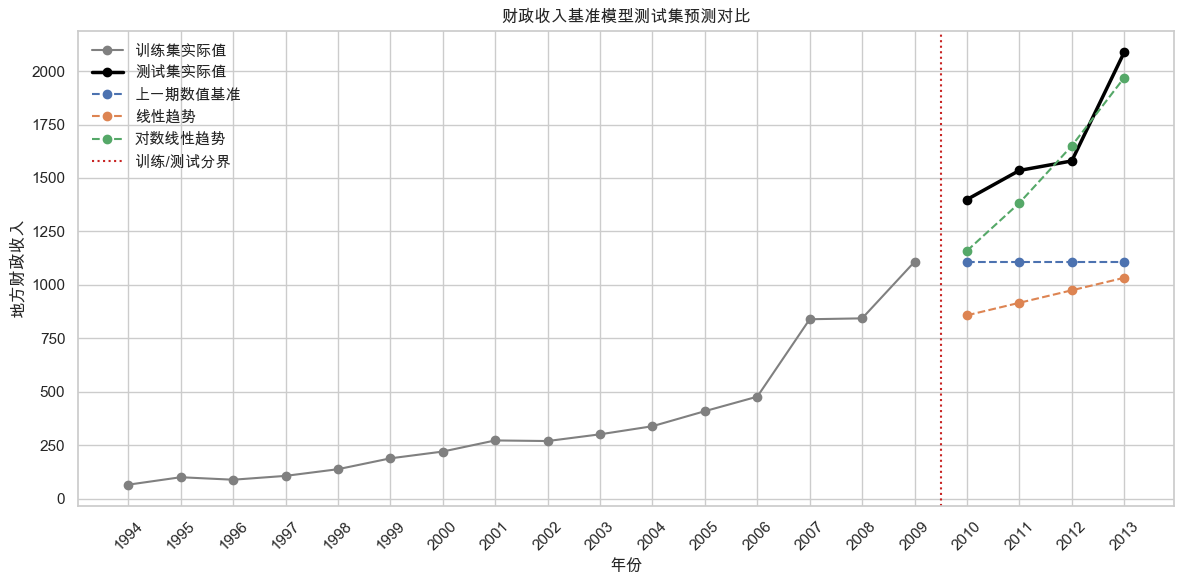

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    train_data["year"],
    y_train,
    color="#808080",
    marker="o",
    label="训练集实际值"
)

ax.plot(
    test_data["year"],
    y_test,
    color="#000000",
    marker="o",
    linewidth=2.5,
    label="测试集实际值"
)

ax.plot(
    test_data["year"],
    last_value_prediction,
    marker="o",
    linestyle="--",
    label="上一期数值基准"
)

ax.plot(
    test_data["year"],
    linear_trend_prediction,
    marker="o",
    linestyle="--",
    label="线性趋势"
)

ax.plot(
    test_data["year"],
    log_trend_prediction,
    marker="o",
    linestyle="--",
    label="对数线性趋势"
)

ax.axvline(
    2009.5,
    color="#C82423",
    linestyle=":",
    label="训练/测试分界"
)

ax.set_title("财政收入基准模型测试集预测对比")
ax.set_xlabel("年份")
ax.set_ylabel("地方财政收入")
ax.set_xticks(data["year"])
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

#### 基准模型评估结论

在2010—2013年测试集上，对数线性趋势模型表现最好，MAPE为9.31%，R²为0.634。相比之下，上一期数值基准的MAPE为31.38%，普通线性趋势的MAPE为41.98%，两者的R²均为负。

普通线性趋势和上一期数值基准都明显低估了后期财政收入，说明财政收入更接近按比例增长的复合增长过程，而不是每年增加固定金额。

因此，将对数线性趋势模型作为后续正则化模型需要超过的主要基准。

### 6.3 对数差分正则化模型

由于原始财政收入和多数宏观经济指标都具有明显增长趋势，直接使用原始水平值建模可能产生伪回归。本项目对全部正数变量取自然对数并进行一阶差分，用年度对数变化近似变量增长率。

建模流程将特征标准化放入Pipeline内部，并使用时间序列交叉验证选择参数，避免测试集信息提前进入训练过程。

测试期模型使用2010—2013年的实际宏观经济指标变化，因此这一阶段评估的是宏观指标已知条件下的条件预测能力，而不是完全未知条件下的独立未来预测。

In [17]:
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet

# 所有变量均为正数，计算年度对数变化
log_change_data = (
    np.log(data[analysis_cols])
    .diff()
    .dropna()
)

log_change_data.insert(
    0,
    "year",
    data["year"].iloc[1:].to_numpy()
)

# 按照原有时间分界划分
growth_train = log_change_data[
    log_change_data["year"] <= 2009
].copy()

growth_test = log_change_data[
    log_change_data["year"] >= 2010
].copy()

X_growth_train = growth_train[feature_cols]
X_growth_test = growth_test[feature_cols]

y_growth_train = growth_train[target_col]
y_growth_test = growth_test[target_col]

print("对数差分训练集：", X_growth_train.shape)
print("对数差分测试集：", X_growth_test.shape)

assert target_col not in X_growth_train.columns
assert target_col not in X_growth_test.columns

对数差分训练集： (15, 13)
对数差分测试集： (4, 13)


#### 6.3.1 Ridge回归

Ridge使用L2正则化同时压缩全部变量系数，适合处理解释变量高度相关的问题。

模型使用4折时间序列交叉验证选择惩罚系数 `alpha`。搜索范围设置为 $10^{-4}$ 至 $10^8$，用于判断模型在不同正则化强度下的验证表现。

In [18]:
time_cv = TimeSeriesSplit(n_splits=4)

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_parameters = {
    "model__alpha": np.logspace(-4, 8, 120)
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_parameters,
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    n_jobs=-1
)

ridge_search.fit(
    X_growth_train,
    y_growth_train
)

ridge_growth_prediction = ridge_search.predict(
    X_growth_test
)

print("Ridge最佳参数：", ridge_search.best_params_)

Ridge最佳参数： {'model__alpha': 100000000.0}


#### 6.3.2 Elastic Net

Elastic Net同时结合L1和L2正则化：

- L1部分可以将部分不稳定变量的系数压缩为0；
- L2部分能够缓解高度相关变量造成的系数波动。

模型通过时间序列交叉验证同时选择正则化强度 `alpha` 和L1比例 `l1_ratio`，并将最大迭代次数提高，以保证模型能够稳定收敛。

In [19]:
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        ElasticNet(
            max_iter=200000,
            random_state=42
        )
    )
])

elastic_parameters = {
    "model__alpha": np.logspace(-4, 3, 80),
    "model__l1_ratio": [
        0.10,
        0.30,
        0.50,
        0.70,
        0.90,
        0.95
    ]
}

elastic_search = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_parameters,
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    n_jobs=-1
)

elastic_search.fit(
    X_growth_train,
    y_growth_train
)

elastic_growth_prediction = elastic_search.predict(
    X_growth_test
)

print("Elastic Net最佳参数：",
      elastic_search.best_params_)

Elastic Net最佳参数： {'model__alpha': 0.024683404670686485, 'model__l1_ratio': 0.95}


#### 6.3.3 测试集预测与模型比较

Ridge和Elastic Net预测的是财政收入年度对数变化。为了获得2010—2013年的财政收入水平预测值，以2009年实际财政收入为起点，将预测的年度对数增长率逐年累计还原。

随后在同一测试集上比较基准模型、Ridge和Elastic Net的MAE、RMSE、MAPE与R²。

In [20]:
# 以2009年实际财政收入为预测起点
forecast_start_value = y_train.iloc[-1]

ridge_prediction = (
    forecast_start_value
    * np.exp(
        np.cumsum(ridge_growth_prediction)
    )
)

elastic_prediction = (
    forecast_start_value
    * np.exp(
        np.cumsum(elastic_growth_prediction)
    )
)

regularized_predictions = pd.DataFrame({
    "year": test_data["year"].values,
    "实际值": y_test.values,
    "Ridge预测值": ridge_prediction,
    "Elastic Net预测值": elastic_prediction
})

regularized_results = pd.DataFrame([
    calculate_regression_metrics(
        "对数差分Ridge",
        y_test,
        ridge_prediction
    ),
    calculate_regression_metrics(
        "对数差分Elastic Net",
        y_test,
        elastic_prediction
    )
])

model_comparison = pd.concat(
    [
        baseline_results,
        regularized_results
    ],
    ignore_index=True
).sort_values("MAPE")

display(
    model_comparison.style.format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE": "{:.2f}%",
        "R²": "{:.3f}"
    })
)

display(
    regularized_predictions.style.format({
        "实际值": "{:.2f}",
        "Ridge预测值": "{:.2f}",
        "Elastic Net预测值": "{:.2f}"
    })
)

,模型,MAE,RMSE,MAPE,R²
4,对数差分Elastic Net,100.03,129.53,6.18%,0.754
0,对数线性趋势,145.44,158.04,9.31%,0.634
3,对数差分Ridge,197.36,237.00,11.61%,0.177
1,上一期数值基准,542.86,602.46,31.38%,-4.318
2,线性趋势,705.37,734.29,41.98%,-6.899


,year,实际值,Ridge预测值,Elastic Net预测值
0,2010,1399.16,1338.35,1361.75
1,2011,1535.14,1617.06,1590.57
2,2012,1579.68,1953.82,1821.17
3,2013,2088.14,2360.70,2153.92


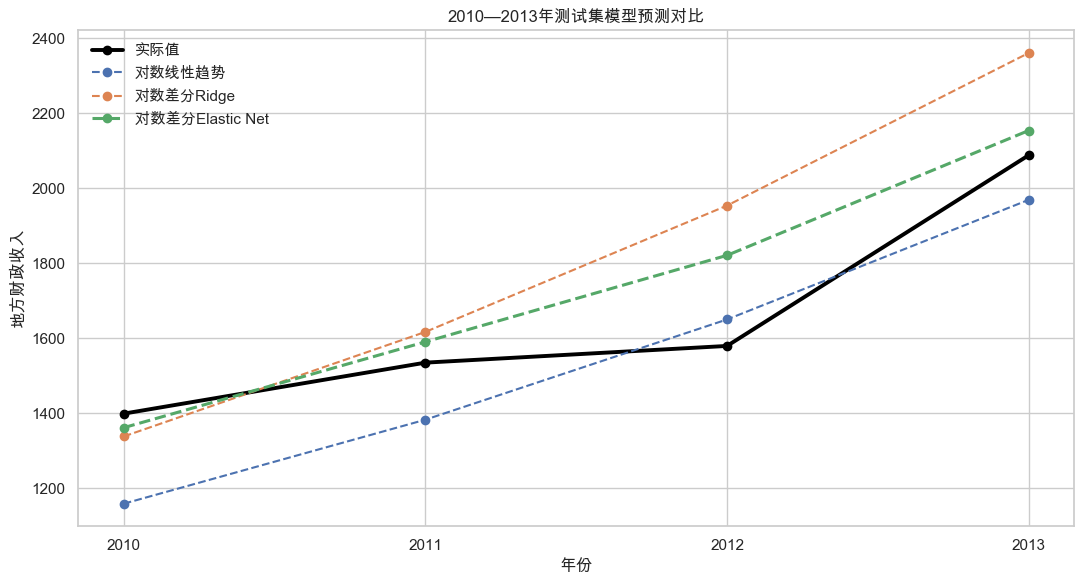

In [21]:
test_model_predictions = pd.DataFrame({
    "year": test_data["year"].values,
    "实际值": y_test.values,
    "对数线性趋势": log_trend_prediction,
    "对数差分Ridge": ridge_prediction,
    "对数差分Elastic Net": elastic_prediction
})

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    test_model_predictions["year"],
    test_model_predictions["实际值"],
    color="#000000",
    marker="o",
    linewidth=2.8,
    label="实际值"
)

ax.plot(
    test_model_predictions["year"],
    test_model_predictions["对数线性趋势"],
    marker="o",
    linestyle="--",
    label="对数线性趋势"
)

ax.plot(
    test_model_predictions["year"],
    test_model_predictions["对数差分Ridge"],
    marker="o",
    linestyle="--",
    label="对数差分Ridge"
)

ax.plot(
    test_model_predictions["year"],
    test_model_predictions["对数差分Elastic Net"],
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="对数差分Elastic Net"
)

ax.set_title("2010—2013年测试集模型预测对比")
ax.set_xlabel("年份")
ax.set_ylabel("地方财政收入")
ax.set_xticks(test_model_predictions["year"])
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [22]:
test_model_predictions["Elastic Net预测误差"] = (
    test_model_predictions["对数差分Elastic Net"]
    - test_model_predictions["实际值"]
)

test_model_predictions["Elastic Net绝对百分比误差"] = (
    test_model_predictions["Elastic Net预测误差"].abs()
    / test_model_predictions["实际值"]
    * 100
)

display(
    test_model_predictions.style.format({
        "实际值": "{:.2f}",
        "对数线性趋势": "{:.2f}",
        "对数差分Ridge": "{:.2f}",
        "对数差分Elastic Net": "{:.2f}",
        "Elastic Net预测误差": "{:.2f}",
        "Elastic Net绝对百分比误差": "{:.2f}%"
    })
)

,year,实际值,对数线性趋势,对数差分Ridge,对数差分Elastic Net,Elastic Net预测误差,Elastic Net绝对百分比误差
0,2010,1399.16,1159.09,1338.35,1361.75,-37.41,2.67%
1,2011,1535.14,1383.05,1617.06,1590.57,55.43,3.61%
2,2012,1579.68,1650.29,1953.82,1821.17,241.49,15.29%
3,2013,2088.14,1969.16,2360.70,2153.92,65.78,3.15%


#### 6.3.4 Elastic Net变量筛选

进一步提取最佳Elastic Net模型的标准化系数，观察模型在严重多重共线性条件下保留了哪些宏观经济指标。

由于系数对应标准化后的年度对数变化，可以比较其相对大小。但变量是否被保留可能受到样本区间和共线性影响，因此不能将系数直接解释为因果效应。

In [23]:
best_elastic_model = (
    elastic_search
    .best_estimator_
    .named_steps["model"]
)

elastic_coefficients = pd.DataFrame({
    "变量": feature_cols,
    "变量名称": [
        variable_names[col]
        for col in feature_cols
    ],
    "标准化系数": best_elastic_model.coef_
})

elastic_coefficients["绝对系数"] = (
    elastic_coefficients["标准化系数"].abs()
)

elastic_coefficients["是否保留"] = np.where(
    elastic_coefficients["绝对系数"] > 1e-8,
    "保留",
    "压缩为0"
)

elastic_coefficients = (
    elastic_coefficients
    .sort_values("绝对系数", ascending=False)
)

display(
    elastic_coefficients.style.format({
        "标准化系数": "{:.4f}",
        "绝对系数": "{:.4f}"
    })
)

,变量,变量名称,标准化系数,绝对系数,是否保留
9,x10,税收,0.0830,0.0830,保留
4,x5,城镇居民人均消费性支出,0.0383,0.0383,保留
10,x11,居民消费价格指数,-0.0034,0.0034,保留
0,x1,社会从业人数,-0.0000,0.0000,压缩为0
1,x2,在岗职工工资总额,0.0000,0.0000,压缩为0
2,x3,社会消费品零售总额,-0.0000,0.0000,压缩为0
3,x4,城镇居民人均可支配收入,-0.0000,0.0000,压缩为0
5,x6,年末总人口,0.0000,0.0000,压缩为0
6,x7,全社会固定资产投资额,0.0000,0.0000,压缩为0
7,x8,地区生产总值,-0.0000,0.0000,压缩为0


#### 固定测试集模型结论

在2010—2013年固定测试集上：

- 对数差分Elastic Net的MAPE为6.18%，R²为0.754；
- 对数线性趋势的MAPE为9.31%，R²为0.634；
- 对数差分Ridge的MAPE为11.61%，R²为0.177。

Elastic Net在固定测试集上表现最好，比对数线性趋势的MAPE降低约3.13个百分点。但Elastic Net在2012年高估财政收入约15.29%，说明模型仍可能受到年度波动影响。

Ridge选择了非常大的惩罚系数 \(10^8\)，而扩大搜索范围后模型指标几乎没有变化。这说明Ridge倾向于将宏观变量系数压缩至接近0，主要按照训练期平均增长率进行预测。

Elastic Net主要保留了税收、城镇居民人均消费性支出和居民消费价格指数。其中，税收的标准化系数绝对值最大，居民消费价格指数的系数则接近0。其余变量被压缩为0，并不代表这些指标与财政收入完全无关，而是说明在高度共线的数据中，模型只保留了少量代表变量。

固定测试集只有4个年度，单次划分结果可能受测试年份选择影响。因此，还需要通过更长区间的滚动时间序列回测检验模型表现和变量选择是否稳定。

### 6.4 滚动时间序列回测

使用2004—2013年作为滚动预测年份。对于每一个预测年份，仅使用该年份之前的数据训练模型，并在训练数据内部重新进行时间序列交叉验证。

滚动回测可以检验模型在不同训练区间下的预测表现，同时观察Elastic Net的最佳参数和保留变量是否稳定。

In [24]:
rolling_records = []

rolling_years = range(2004, 2014)

for forecast_year in rolling_years:

    # 预测年份之前的原始数据
    rolling_train_data = data[
        data["year"] < forecast_year
    ].copy()

    rolling_test_data = data[
        data["year"] == forecast_year
    ].copy()

    # 预测年份之前的对数差分数据
    rolling_growth_train = log_change_data[
        log_change_data["year"] < forecast_year
    ].copy()

    rolling_growth_test = log_change_data[
        log_change_data["year"] == forecast_year
    ].copy()

    # 基准1：上一年度实际值
    previous_value_prediction = (
        rolling_train_data[target_col].iloc[-1]
    )

    # 基准2：根据此前所有年份建立对数线性趋势
    rolling_log_trend = LinearRegression()

    rolling_log_trend.fit(
        rolling_train_data[["year"]],
        np.log(
            rolling_train_data[target_col]
        )
    )

    rolling_log_trend_prediction = np.exp(
        rolling_log_trend.predict(
            rolling_test_data[["year"]]
        )[0]
    )

    # Elastic Net内部时间序列调参
    rolling_elastic_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            ElasticNet(
                max_iter=200000,
                random_state=42
            )
        )
    ])

    rolling_elastic_parameters = {
        "model__alpha": np.logspace(
            -4,
            3,
            80
        ),
        "model__l1_ratio": [
            0.10,
            0.30,
            0.50,
            0.70,
            0.90,
            0.95
        ]
    }

    rolling_inner_cv = TimeSeriesSplit(
        n_splits=3
    )

    rolling_elastic_search = GridSearchCV(
        estimator=rolling_elastic_pipeline,
        param_grid=rolling_elastic_parameters,
        scoring="neg_mean_absolute_error",
        cv=rolling_inner_cv,
        n_jobs=-1
    )

    rolling_elastic_search.fit(
        rolling_growth_train[feature_cols],
        rolling_growth_train[target_col]
    )

    predicted_log_growth = (
        rolling_elastic_search.predict(
            rolling_growth_test[feature_cols]
        )[0]
    )

    # 使用上一年度实际收入还原本年度预测值
    rolling_elastic_prediction = (
        previous_value_prediction
        * np.exp(predicted_log_growth)
    )

    rolling_best_model = (
        rolling_elastic_search
        .best_estimator_
        .named_steps["model"]
    )

    selected_features = [
        feature_cols[index]
        for index, coefficient
        in enumerate(rolling_best_model.coef_)
        if abs(coefficient) > 1e-8
    ]

    rolling_records.append({
        "year": forecast_year,
        "实际值": rolling_test_data[
            target_col
        ].iloc[0],
        "上一年度基准": previous_value_prediction,
        "对数线性趋势": rolling_log_trend_prediction,
        "Elastic Net": rolling_elastic_prediction,
        "最佳alpha": (
            rolling_elastic_search
            .best_params_["model__alpha"]
        ),
        "最佳l1_ratio": (
            rolling_elastic_search
            .best_params_["model__l1_ratio"]
        ),
        "保留变量数量": len(selected_features),
        "保留变量": "、".join(selected_features)
    })

rolling_predictions = pd.DataFrame(
    rolling_records
)

display(
    rolling_predictions.style.format({
        "实际值": "{:.2f}",
        "上一年度基准": "{:.2f}",
        "对数线性趋势": "{:.2f}",
        "Elastic Net": "{:.2f}",
        "最佳alpha": "{:.6f}",
        "最佳l1_ratio": "{:.2f}"
    })
)

,year,实际值,上一年度基准,对数线性趋势,Elastic Net,最佳alpha,最佳l1_ratio,保留变量数量,保留变量
0,2004,338.45,300.55,403.60,349.54,0.024683,0.90,1,x10
1,2005,408.86,338.45,450.99,422.44,0.016413,0.95,1,x10
2,2006,476.72,408.86,515.84,493.26,0.016413,0.95,1,x10
3,2007,838.99,476.72,592.77,582.83,0.024683,0.95,1,x10
4,2008,843.14,838.99,768.72,1072.30,0.016413,0.95,5,x2、x5、x8、x9、x10
5,2009,1107.67,843.14,934.46,971.66,0.013384,0.90,5,x2、x4、x5、x10、x11
6,2010,1399.16,1107.67,1159.09,915.63,0.000100,0.50,12,x1、x2、x3、x4、x5、x6、x7、x9、x10、x11、x12、x13
7,2011,1535.14,1399.16,1445.69,1724.19,0.016413,0.90,5,x2、x5、x8、x10、x11
8,2012,1579.68,1535.14,1754.66,1759.93,0.037121,0.90,2,x5、x10
9,2013,2088.14,1579.68,2057.64,1854.61,0.030270,0.90,2,x5、x10


In [25]:
rolling_results = pd.DataFrame([
    calculate_regression_metrics(
        "上一年度基准",
        rolling_predictions["实际值"],
        rolling_predictions["上一年度基准"]
    ),
    calculate_regression_metrics(
        "对数线性趋势",
        rolling_predictions["实际值"],
        rolling_predictions["对数线性趋势"]
    ),
    calculate_regression_metrics(
        "对数差分Elastic Net",
        rolling_predictions["实际值"],
        rolling_predictions["Elastic Net"]
    )
]).sort_values("MAPE")

display(
    rolling_results.style.format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE": "{:.2f}%",
        "R²": "{:.3f}"
    })
)

,模型,MAE,RMSE,MAPE,R²
1,对数线性趋势,117.52,141.74,12.71%,0.934
2,对数差分Elastic Net,174.89,222.21,14.95%,0.838
0,上一年度基准,178.76,240.04,16.71%,0.811


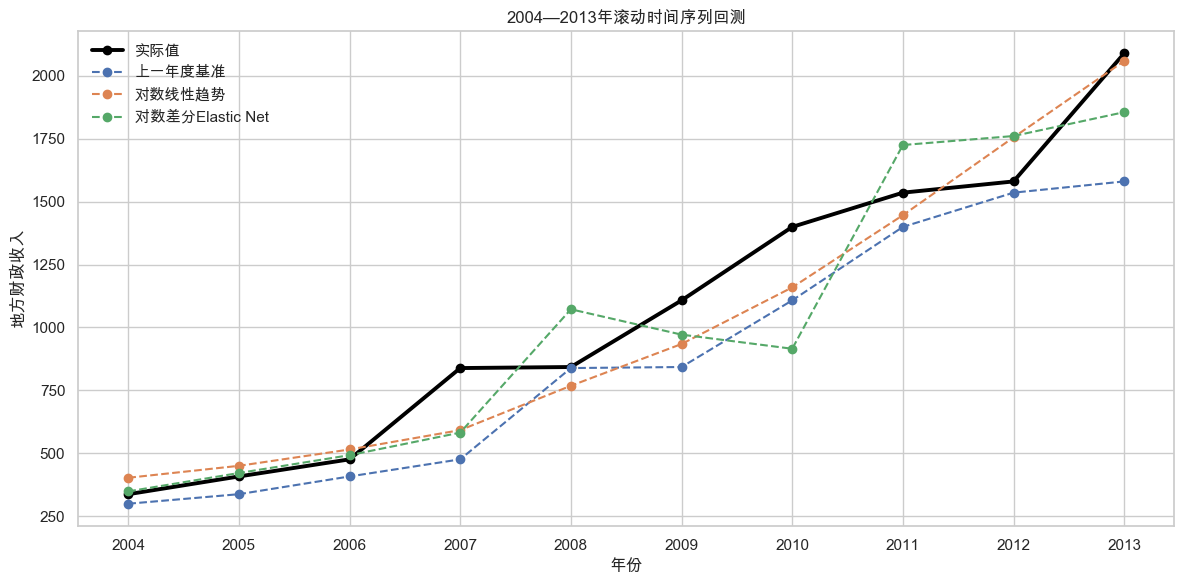

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rolling_predictions["year"],
    rolling_predictions["实际值"],
    color="#000000",
    marker="o",
    linewidth=2.8,
    label="实际值"
)

ax.plot(
    rolling_predictions["year"],
    rolling_predictions["上一年度基准"],
    marker="o",
    linestyle="--",
    label="上一年度基准"
)

ax.plot(
    rolling_predictions["year"],
    rolling_predictions["对数线性趋势"],
    marker="o",
    linestyle="--",
    label="对数线性趋势"
)

ax.plot(
    rolling_predictions["year"],
    rolling_predictions["Elastic Net"],
    marker="o",
    linestyle="--",
    label="对数差分Elastic Net"
)

ax.set_title("2004—2013年滚动时间序列回测")
ax.set_xlabel("年份")
ax.set_ylabel("地方财政收入")
ax.set_xticks(rolling_predictions["year"])
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

#### 滚动时间序列回测结论

在2004—2013年的逐年滚动回测中：

- 对数线性趋势模型的MAPE为12.71%，R²为0.934；
- 对数差分Elastic Net的MAPE为14.95%，R²为0.838；
- 上一年度数值基准的MAPE为16.71%，R²为0.811。

Elastic Net虽然在固定2010—2013年测试集上取得最低误差，但没有在更长时间范围的滚动回测中保持领先。对数线性趋势模型的整体预测表现更加稳定。

Elastic Net在不同滚动窗口中保留的变量数量从1个变化到12个，最佳参数也存在明显波动，说明变量筛选结果对训练区间较为敏感。税收是最稳定被保留的变量，城镇居民人均消费性支出也在多个后期窗口中被选择。

综合固定测试集和滚动回测结果，选择对数线性趋势作为最终主要预测模型。Elastic Net用于辅助分析宏观经济指标变化与财政收入增长之间的条件关联，不作为唯一的未来预测模型。

## 7. 2014—2015年财政收入预测

### 7.1 最终模型拟合与预测区间

使用全部1994—2013年数据重新拟合对数线性趋势模型，并预测2014年和2015年的地方财政收入。

由于模型在对数尺度上训练，将预测结果还原到原始尺度时使用指数还原偏差修正系数。同时根据训练期对数残差计算95%近似预测区间，用于反映未来预测的不确定性。

In [27]:
from scipy.stats import t as student_t

# 使用全部历史数据拟合最终模型
final_log_trend_model = LinearRegression()

final_log_trend_model.fit(
    data[["year"]],
    np.log(data[target_col])
)

# 未来预测年份
future_years = pd.DataFrame({
    "year": [2014, 2015]
})

# 对数尺度预测
future_log_prediction = (
    final_log_trend_model.predict(
        future_years[["year"]]
    )
)

# 训练期拟合值与残差
fitted_log_values = (
    final_log_trend_model.predict(
        data[["year"]]
    )
)

log_residuals = (
    np.log(data[target_col])
    - fitted_log_values
)

# 指数还原的偏差修正系数
smearing_factor = np.mean(
    np.exp(log_residuals)
)

future_point_prediction = (
    np.exp(future_log_prediction)
    * smearing_factor
)

# 计算95%近似预测区间
sample_size = len(data)
degrees_of_freedom = sample_size - 2

year_mean = data["year"].mean()

year_squared_deviation = (
    (data["year"] - year_mean) ** 2
).sum()

residual_standard_error = np.sqrt(
    (log_residuals ** 2).sum()
    / degrees_of_freedom
)

critical_value = student_t.ppf(
    0.975,
    degrees_of_freedom
)

prediction_standard_error = (
    residual_standard_error
    * np.sqrt(
        1
        + 1 / sample_size
        + (
            (future_years["year"] - year_mean) ** 2
            / year_squared_deviation
        )
    )
)

lower_bound = (
    np.exp(
        future_log_prediction
        - critical_value
        * prediction_standard_error
    )
    * smearing_factor
)

upper_bound = (
    np.exp(
        future_log_prediction
        + critical_value
        * prediction_standard_error
    )
    * smearing_factor
)

future_forecast = pd.DataFrame({
    "year": future_years["year"],
    "财政收入点预测": future_point_prediction,
    "95%预测下限": lower_bound,
    "95%预测上限": upper_bound
})

implied_growth_rate = (
    np.exp(
        final_log_trend_model.coef_[0]
    )
    - 1
)

print(
    f"模型隐含年度增长率："
    f"{implied_growth_rate:.2%}"
)

print(
    f"指数还原偏差修正系数："
    f"{smearing_factor:.4f}"
)

display(
    future_forecast.style.format({
        "财政收入点预测": "{:.2f}",
        "95%预测下限": "{:.2f}",
        "95%预测上限": "{:.2f}"
    })
)

模型隐含年度增长率：19.72%
指数还原偏差修正系数：1.0078


,year,财政收入点预测,95%预测下限,95%预测上限
0,2014,2489.35,1835.38,3376.33
1,2015,2980.15,2188.22,4058.70


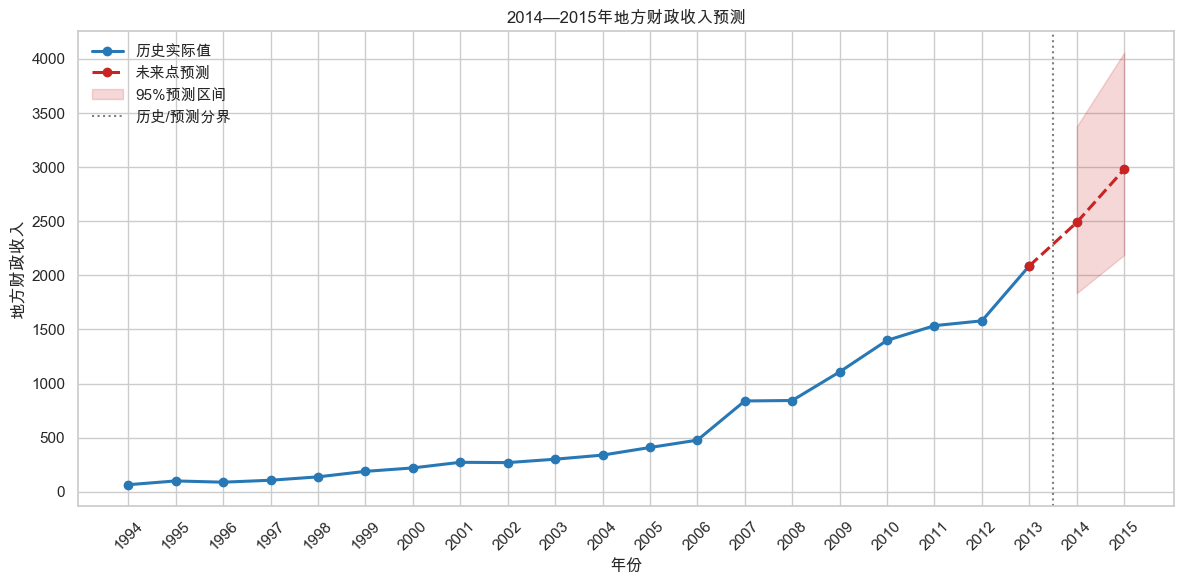

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    data["year"],
    data[target_col],
    color="#2878B5",
    marker="o",
    linewidth=2.2,
    label="历史实际值"
)

forecast_line_years = np.array([
    2013,
    2014,
    2015
])

forecast_line_values = np.concatenate([
    [data[target_col].iloc[-1]],
    future_forecast[
        "财政收入点预测"
    ].to_numpy()
])

ax.plot(
    forecast_line_years,
    forecast_line_values,
    color="#C82423",
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="未来点预测"
)

ax.fill_between(
    future_forecast["year"],
    future_forecast["95%预测下限"],
    future_forecast["95%预测上限"],
    color="#C82423",
    alpha=0.18,
    label="95%预测区间"
)

ax.axvline(
    2013.5,
    color="gray",
    linestyle=":",
    label="历史/预测分界"
)

ax.set_title("2014—2015年地方财政收入预测")
ax.set_xlabel("年份")
ax.set_ylabel("地方财政收入")
ax.set_xticks(
    list(data["year"])
    + [2014, 2015]
)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### 7.2 最终预测结果

使用全部历史数据重新拟合后，模型隐含的长期年度增长率约为19.72%，指数还原偏差修正系数为1.0078。

最终预测结果为：

- 2014年财政收入点预测为2489.35，95%近似预测区间为1835.38—3376.33；
- 2015年财政收入点预测为2980.15，95%近似预测区间为2188.22—4058.70。

2015年的预测区间宽于2014年，反映了预测期延长带来的不确定性增加。预测结果建立在历史增长模式继续延续的假设上，如果未来发生政策调整、经济周期变化或其他宏观冲击，实际财政收入可能偏离预测范围。

由于原始资料没有注明财政收入的统计单位，预测值沿用原始数据单位，不额外推断其币种或金额口径。

## 8. 最终模型诊断

### 8.1 残差分布与时间相关性

最终预测区间依赖对数线性趋势模型的残差假设，因此进一步检查残差的缺失情况、正态性和一阶时间相关性。

使用Shapiro-Wilk检验和正态Q-Q图检查残差分布，并计算残差一阶自相关系数，观察模型是否遗漏明显的时间结构。

In [29]:
from scipy.stats import shapiro, probplot

# 使用to_numpy()取消原索引，按照位置重新绑定年份
final_residuals = pd.Series(
    data=log_residuals.to_numpy(),
    index=data["year"].to_numpy(),
    name="对数残差"
)

# 检查残差是否完整
print("残差数量：", len(final_residuals))
print("残差缺失值：", final_residuals.isna().sum())

assert final_residuals.notna().all()

shapiro_statistic, shapiro_p_value = (
    shapiro(final_residuals)
)

lag1_autocorrelation = (
    final_residuals.autocorr(lag=1)
)

print(
    f"Shapiro-Wilk统计量："
    f"{shapiro_statistic:.4f}"
)

print(
    f"Shapiro-Wilk p值："
    f"{shapiro_p_value:.4f}"
)

print(
    f"残差一阶自相关系数："
    f"{lag1_autocorrelation:.4f}"
)

残差数量： 20
残差缺失值： 0
Shapiro-Wilk统计量：0.9554
Shapiro-Wilk p值：0.4572
残差一阶自相关系数：0.2636


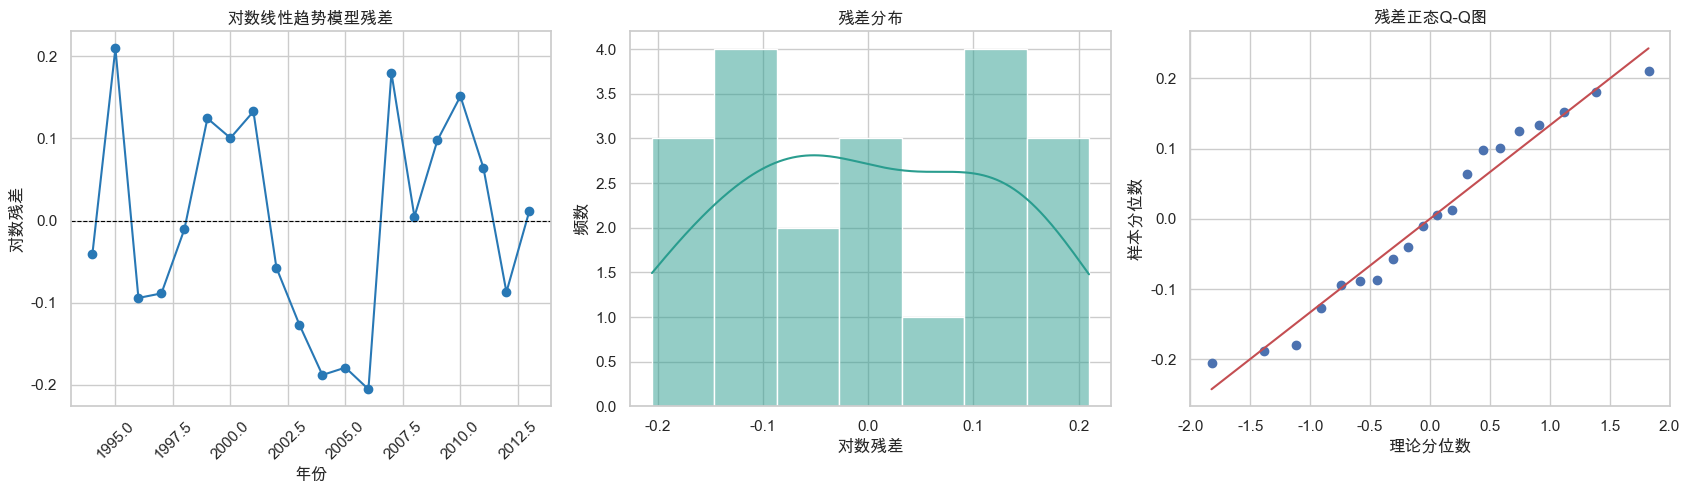

In [30]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(17, 5)
)

# 残差时间趋势
axes[0].plot(
    data["year"],
    final_residuals.values,
    marker="o",
    color="#2878B5"
)

axes[0].axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

axes[0].set_title("对数线性趋势模型残差")
axes[0].set_xlabel("年份")
axes[0].set_ylabel("对数残差")
axes[0].tick_params(
    axis="x",
    rotation=45
)

# 残差分布
sns.histplot(
    final_residuals,
    bins=7,
    kde=True,
    color="#2A9D8F",
    ax=axes[1]
)

axes[1].set_title("残差分布")
axes[1].set_xlabel("对数残差")
axes[1].set_ylabel("频数")

# 正态Q-Q图
probplot(
    final_residuals,
    dist="norm",
    plot=axes[2]
)

axes[2].set_title("残差正态Q-Q图")
axes[2].set_xlabel("理论分位数")
axes[2].set_ylabel("样本分位数")

plt.tight_layout()
plt.show()

#### 残差诊断结论

残差诊断结果显示：

- 20个残差均计算成功，不存在缺失值；
- Shapiro-Wilk统计量为0.9554；
- Shapiro-Wilk检验p值为0.4572；
- 残差一阶自相关系数为0.2636。

Shapiro-Wilk检验的p值大于0.05，因此在当前样本下没有充分证据拒绝残差服从正态分布的假设。正态Q-Q图中的大部分观测点也接近参考直线，说明残差分布总体上没有出现严重偏离。

残差存在轻微正时间相关。残差时间图还显示，2003—2006年的残差连续为负，而2007年明显转为正值，可能反映这一阶段存在对数线性趋势未完全捕捉到的结构变化。

由于样本仅包含20个年度，正态性检验和自相关判断的统计能力有限。因此，本项目给出的95%预测区间应理解为基于对数线性趋势假设的近似不确定性范围。

## 9. 项目总结

本项目使用1994—2013年共20个年度样本，分析13项宏观经济指标与地方财政收入之间的关联，并预测2014年和2015年的财政收入。

### 9.1 主要发现

- 1994—2013年地方财政收入从64.87增长至2088.14，复合年均增长率约为20.05%，但不同年份的增长速度存在明显波动。
- 多数宏观经济指标在原始数值层面与财政收入高度相关，但这些变量本身也与年份高度相关，说明原始相关性受到共同增长趋势影响。
- 一阶差分后，固定资产投资、地区生产总值、税收、社会消费品零售总额和居民消费支出的变化仍与财政收入变化保持一定正相关。
- 解释变量之间存在严重多重共线性。除居民消费价格指数外，大多数变量的VIF远高于10。
- 固定测试集上，对数差分Elastic Net取得6.18%的MAPE，但滚动回测MAPE为14.95%，模型优势没有在不同时间窗口中稳定保持。
- 对数线性趋势模型在滚动回测中的MAPE为12.71%，表现更加稳定，因此被选为最终主要预测模型。
- Elastic Net最稳定保留的变量为税收，居民消费性支出也在多个窗口中被选择，但变量筛选结果会随训练区间变化，不能解释为因果关系。

### 9.2 最终预测

使用全部1994—2013年数据重新拟合对数线性趋势模型后：

- 2014年财政收入点预测为2489.35，95%近似预测区间为1835.38—3376.33；
- 2015年财政收入点预测为2980.15，95%近似预测区间为2188.22—4058.70。

### 9.3 项目局限

- 样本仅包含20个年度，模型评估和变量筛选结果具有较大不确定性；
- 原始资料没有明确注明地区和各变量的统计单位；
- 宏观经济指标之间存在严重共线性，无法根据模型系数判断单个变量的因果影响；
- Elastic Net条件预测使用了测试年份的实际宏观指标，不属于完全未知条件下的独立未来预测；
- 最终预测建立在历史增长趋势继续延续的假设上，无法提前反映政策变化、经济周期或突发冲击；
- 残差存在轻微时间相关，预测区间应作为近似范围使用。